# 可视化训练日志-训练过程总体评估指标

训练模型时在`work_dirs`目录生成记录训练日志，解析其中损失函数、评估指标等信息，并可视化。

同济子豪兄：https://space.bilibili.com/1900783

## 设置Matplotlib中文字体

In [1]:
# # windows操作系统
# plt.rcParams['font.sans-serif']=['SimHei']  # 用来正常显示中文标签 
# plt.rcParams['axes.unicode_minus']=False  # 用来正常显示负号

In [2]:
# Mac操作系统，参考 https://www.ngui.cc/51cto/show-727683.html
# 下载 simhei.ttf 字体文件
# !wget https://zihao-openmmlab.obs.cn-east-3.myhuaweicloud.com/20220716-mmclassification/dataset/SimHei.ttf

In [1]:
# Linux操作系统，例如 云GPU平台：https://featurize.cn/?s=d7ce99f842414bfcaea5662a97581bd1
# 如果遇到 SSL 相关报错，重新运行本代码块即可
# !wget https://zihao-openmmlab.obs.cn-east-3.myhuaweicloud.com/20220716-mmclassification/dataset/SimHei.ttf -O /environment/miniconda3/lib/python3.7/site-packages/matplotlib/mpl-data/fonts/ttf/SimHei.ttf
# !rm -rf /home/featurize/.cache/matplotlib

import matplotlib 
import matplotlib.pyplot as plt
matplotlib.rc("font",family='SimHei') # 中文字体


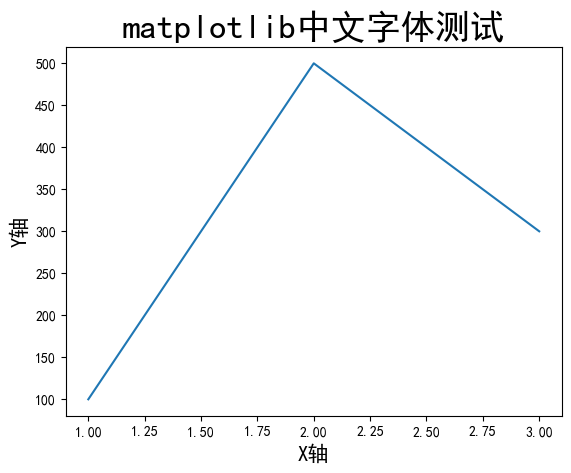

In [2]:
plt.plot([1,2,3], [100,500,300])
plt.title('matplotlib中文字体测试', fontsize=25)
plt.xlabel('X轴', fontsize=15)
plt.ylabel('Y轴', fontsize=15)
plt.show()

## 进入MMSegmentation主目录

In [3]:
# import os
# os.chdir('mmsegmentation')

import os
# 假设 mmsegmentation 的绝对路径是 /project/mmsegmentation
mmsegmentation_path = "E:/bishe_demo/mmsegmentation-main"
# 切换到 mmsegmentation 文件夹
os.chdir(mmsegmentation_path)
# 验证当前工作目录
print("当前工作目录:", os.getcwd())  # 输出: /project/mmsegmentation

当前工作目录: E:\bishe_demo\mmsegmentation-main


In [4]:
os.getcwd()

'E:\\bishe_demo\\mmsegmentation-main'

## 导入工具包

In [5]:
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline

## 载入训练日志

In [6]:
# 日志文件路径
log_path = './work_dirs/ZihaoDataset-Segformer/20250226_000946/vis_data/scalars.json'

In [7]:
with open(log_path, "r") as f:
    json_list = f.readlines()

In [8]:
len(json_list)

110

In [9]:
eval(json_list[4])

{'base_lr': 1.9613655770513682e-06,
 'lr': 1.9613655770513682e-06,
 'data_time': 0.09479813575744629,
 'loss': 2.735790967941284,
 'decode.loss_ce': 2.735790967941284,
 'decode.acc_seg': 6.993782997131348,
 'time': 2.4628315210342406,
 'iter': 50,
 'memory': 5947,
 'step': 50}

In [10]:
import pandas as pd

# 初始化空的 DataFrame
df_train = pd.DataFrame()
df_test = pd.DataFrame()

# 遍历 json_list
for each in json_list[:-1]:
    # 将字符串转换为字典
    data = eval(each)
    
    # 根据条件将数据添加到 df_train 或 df_test
    if 'aAcc' in data:
        df_test = pd.concat([df_test, pd.DataFrame([data])], ignore_index=True)
    else:
        df_train = pd.concat([df_train, pd.DataFrame([data])], ignore_index=True)

In [11]:
df_train

,base_lr,lr,data_time,loss,decode.loss_ce,decode.acc_seg,time,iter,memory,step
0,3.602998e-07,3.602998e-07,0.004559,2.777479,2.777479,0.943974,3.591632,10,6975,10
1,7.605662e-07,7.605662e-07,0.089144,2.814993,2.814993,2.457015,2.479481,20,5947,20
2,1.160833e-06,1.160833e-06,0.076070,2.769450,2.769450,3.004382,2.448550,30,5947,30
3,1.561099e-06,1.561099e-06,0.087585,2.804937,2.804937,3.875421,2.497777,40,5947,40
4,1.961366e-06,1.961366e-06,0.094798,2.735791,2.735791,6.993783,2.462832,50,5947,50
...,...,...,...,...,...,...,...,...,...,...
95,3.838561e-05,3.838561e-05,0.119123,0.496856,0.496856,90.160454,2.556995,960,5947,960
96,3.878588e-05,3.878588e-05,0.080908,0.627312,0.627312,85.613075,2.515897,970,5947,970
97,3.918614e-05,3.918614e-05,0.076905,0.429948,0.429948,73.775291,2.522314,980,5947,980
98,3.958641e-05,3.958641e-05,0.083613,0.450821,0.450821,90.519814,2.533351,990,5947,990


In [12]:
df_test

,aAcc,mIoU,mAcc,data_time,time,step
0,56.53,8.58,13.79,0.025977,0.253786,100
1,75.77,14.08,18.90,0.005712,0.222089,200
2,80.13,16.76,20.95,0.005740,0.225823,300
3,82.50,19.87,23.76,0.005531,0.222844,400
4,84.16,21.84,25.56,0.005667,0.227861,500
5,85.35,25.09,29.08,0.005579,0.223918,600
6,87.35,28.08,33.56,0.005653,0.225225,700
7,88.10,30.33,35.71,0.005349,0.223211,800
8,82.94,31.80,40.65,0.005259,0.220638,900


## 导出训练日志表格

In [13]:
df_train.to_csv('图表/训练日志-训练集.csv', index=False)
df_test.to_csv('图表/训练日志-测试集.csv', index=False)

## 可视化辅助函数

In [14]:
from matplotlib import colors as mcolors
import random
random.seed(124)
colors = ['b', 'g', 'r', 'c', 'm', 'y', 'k', 'tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown', 'tab:pink', 'tab:gray', 'tab:olive', 'tab:cyan', 'black', 'indianred', 'brown', 'firebrick', 'maroon', 'darkred', 'red', 'sienna', 'chocolate', 'yellow', 'olivedrab', 'yellowgreen', 'darkolivegreen', 'forestgreen', 'limegreen', 'darkgreen', 'green', 'lime', 'seagreen', 'mediumseagreen', 'darkslategray', 'darkslategrey', 'teal', 'darkcyan', 'dodgerblue', 'navy', 'darkblue', 'mediumblue', 'blue', 'slateblue', 'darkslateblue', 'mediumslateblue', 'mediumpurple', 'rebeccapurple', 'blueviolet', 'indigo', 'darkorchid', 'darkviolet', 'mediumorchid', 'purple', 'darkmagenta', 'fuchsia', 'magenta', 'orchid', 'mediumvioletred', 'deeppink', 'hotpink']
markers = [".",",","o","v","^","<",">","1","2","3","4","8","s","p","P","*","h","H","+","x","X","D","d","|","_",0,1,2,3,4,5,6,7,8,9,10,11]
linestyle = ['--', '-.', '-']

def get_line_arg():
    '''
    随机产生一种绘图线型
    '''
    line_arg = {}
    line_arg['color'] = random.choice(colors)
    # line_arg['marker'] = random.choice(markers)
    line_arg['linestyle'] = random.choice(linestyle)
    line_arg['linewidth'] = random.randint(1, 4)
    # line_arg['markersize'] = random.randint(3, 5)
    return line_arg

## 训练集损失函数

In [15]:
metrics = ['loss', 'decode.loss_ce', 'aux.loss_ce']

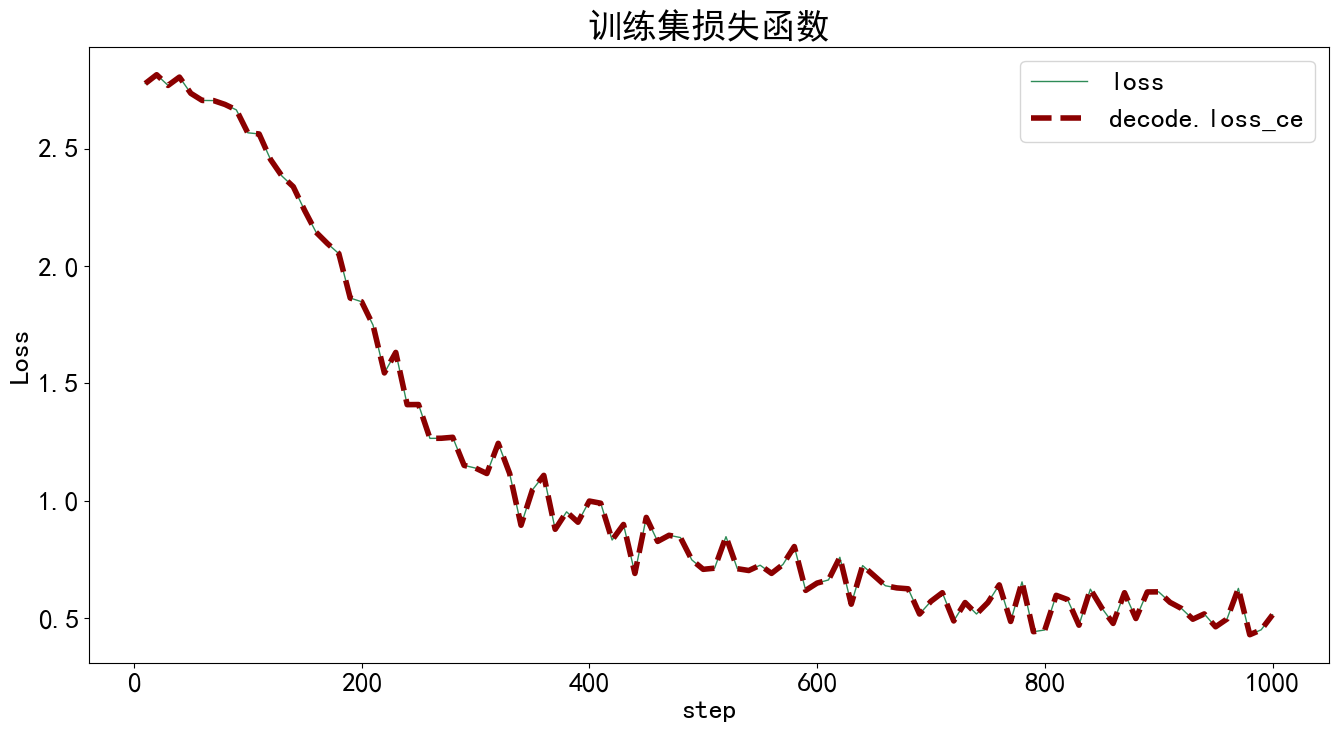

In [16]:
plt.figure(figsize=(16, 8))

x = df_train['step']
for y in metrics:
    try:
        plt.plot(x, df_train[y], label=y, **get_line_arg())
    except:
        pass

plt.tick_params(labelsize=20)
plt.xlabel('step', fontsize=20)
plt.ylabel('Loss', fontsize=20)
plt.title('训练集损失函数', fontsize=25)

plt.legend(fontsize=20)

plt.savefig('图表/训练集损失函数.pdf', dpi=120, bbox_inches='tight')

plt.show()

## 训练集准确率

In [17]:
metrics = ['decode.acc_seg', 'aux.acc_seg']

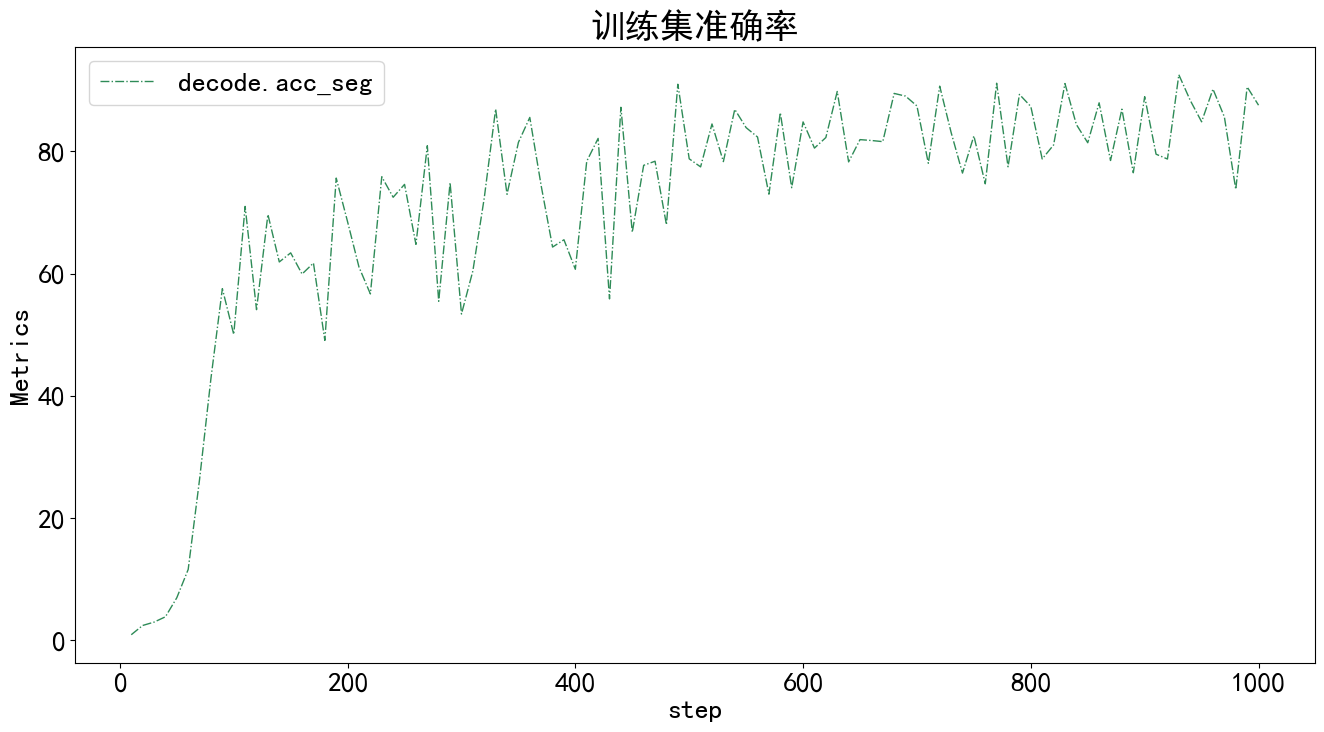

In [18]:
plt.figure(figsize=(16, 8))

x = df_train['step']
for y in metrics:
    try:
        plt.plot(x, df_train[y], label=y, **get_line_arg())
    except:
        pass

plt.tick_params(labelsize=20)
plt.xlabel('step', fontsize=20)
plt.ylabel('Metrics', fontsize=20)
plt.title('训练集准确率', fontsize=25)

plt.legend(fontsize=20)

plt.savefig('图表/训练集准确率.pdf', dpi=120, bbox_inches='tight')

plt.show()

## 测试集评估指标

In [19]:
df_test.columns

Index(['aAcc', 'mIoU', 'mAcc', 'data_time', 'time', 'step'], dtype='object')

In [20]:
metrics = ['aAcc', 'mIoU', 'mAcc', 'mDice', 'mFscore', 'mPrecision', 'mRecall']

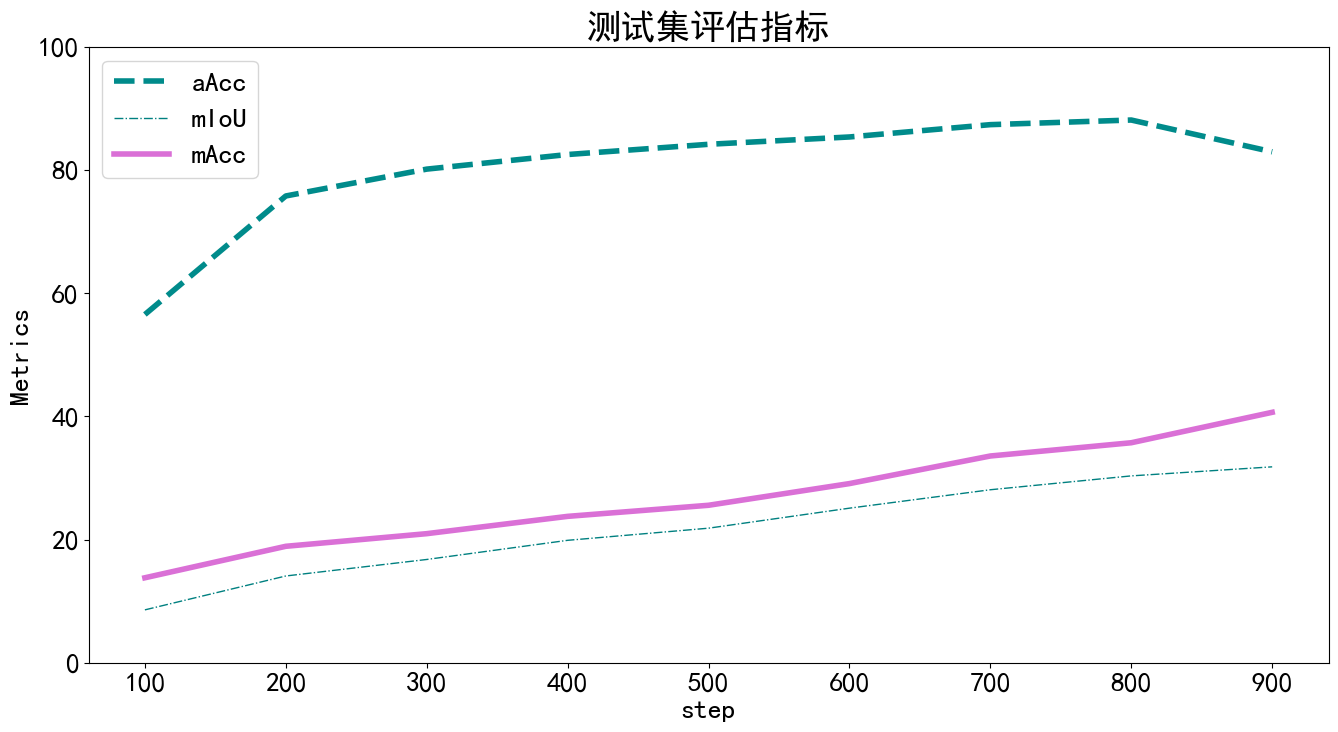

In [21]:
plt.figure(figsize=(16, 8))

x = df_test['step']
for y in metrics:
    try:
        plt.plot(x, df_test[y], label=y, **get_line_arg())
    except:
        pass

plt.tick_params(labelsize=20)
plt.ylim([0, 100])
plt.xlabel('step', fontsize=20)
plt.ylabel('Metrics', fontsize=20)
plt.title('测试集评估指标', fontsize=25)

plt.legend(fontsize=20)

plt.savefig('图表/测试集分类评估指标.pdf', dpi=120, bbox_inches='tight')

plt.show()